Model Page: https://huggingface.co/google/gemma-3-4b-it

In [1]:
import os 
print(os.getenv("CONDA_DEFAULT_ENV"))
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"

stable_env


In [2]:
import json
import torch
import pickle
import random
import datasets
import datetime
import logging

In [3]:
import numpy as np
from tqdm.auto import tqdm
from datasets import Dataset
from functools import partial
from torch.optim import AdamW
from datasets import load_dataset
from torch.utils.data import DataLoader

In [4]:
import os 
print(os.getenv("CONDA_DEFAULT_ENV"))
os.environ["TOKENIZERS_PARALLELISM"] = "false"

stable_env


In [5]:
from qwen_vl_utils import process_vision_info

### Set up Logger

In [6]:
# Clear previous handlers to avoid duplicate logs in Jupyter
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Change to DEBUG for more verbosity
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]  # Ensures it logs to Jupyter cell output
)

logger = logging.getLogger(__name__)
logger.info("Logging is set up in the notebook!")

2026-03-08 18:18:38,240 - INFO - Logging is set up in the notebook!


### Force Determinism

In [7]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

### Load the MultiDomain Dataset

In [8]:
prefix = "Generate Step by Step Thought and the final answer from the given image and question"

In [9]:
def prepend_prefix(example):
    example['question'] = prefix + ': ' + example['question']
    return example

In [10]:
def ensure_rgb_batch(batch):
    if "image" in batch:
        batch["image"] = [img.convert("RGB") for img in batch["image"]]
    return batch

In [11]:
dataset = load_dataset("dutta18/multi-domain-VQA-12K")

In [12]:
train_set, val_set = dataset['train'], dataset['validation']

In [13]:
train_set = train_set.map(prepend_prefix)
val_set = val_set.map(prepend_prefix)

In [14]:
train_set = train_set.with_transform(ensure_rgb_batch)
val_set = val_set.with_transform(ensure_rgb_batch)

In [15]:
len(train_set), len(val_set)

(12000, 2400)

In [16]:
set(train_set['reasoning_type'])

{'commonsense', 'pathology', 'physical', 'quantity'}

### Import COT Data

In [17]:
with open('/home/aritrad/MOE-Directory/COT-Data-Multidomain-12K/COT-train-set-12K.pkl', 'rb') as file:
    COT_train = pickle.load(file)

with open('/home/aritrad/MOE-Directory/COT-Data-Multidomain-12K/COT-val-set-12K.pkl', 'rb') as file:
    COT_val = pickle.load(file)

In [18]:
# Replace the markdowns * and #:

COT_train = [ data.replace('*', '') for data in COT_train ]
COT_train = [ data.replace('#', '') for data in COT_train ]

COT_val = [ data.replace('*', '') for data in COT_val ]
COT_val = [ data.replace('#', '') for data in COT_val ]

In [19]:
val_set[250], COT_val[250]

({'question': 'Generate Step by Step Thought and the final answer from the given image and question: What are they waiting to do when they stand next to the street?',
  'answer': 'cross',
  'image': <PIL.Image.Image image mode=RGB size=500x375>,
  'reasoning_type': 'commonsense'},
 ' Step-by-Step Thought:\n\n1. I observe a person standing next to the street, looking at the traffic light.\n2. I infer that the person is waiting for the traffic light to change from red to green.\n3. Therefore, the person is waiting to cross the street.\n\n Final Answer: cross')

In [20]:
assert len(train_set) == len(COT_train), "Length mismatch between dataset and COT list."
assert len(val_set) == len(COT_val), "Length mismatch between dataset and COT list."

# Use map with an index to replace the "answer" field
train_set = train_set.map(lambda example, idx: {"cot_answer": COT_train[idx].strip()}, with_indices=True, num_proc=8)
val_set = val_set.map(lambda example, idx: {"cot_answer": COT_val[idx].strip()}, with_indices=True, num_proc=8)

In [21]:
len(train_set), len(val_set)

(12000, 2400)

In [22]:
train_set = train_set.filter(lambda example: example["reasoning_type"] == "physical", num_proc=8)
val_set   = val_set.filter(lambda example: example["reasoning_type"] == "physical", num_proc=8)

In [23]:
len(train_set), len(val_set)

(3000, 600)

### Prepare Dataloaders

In [24]:
from torch.utils.data import Dataset

In [25]:
class MultiDomain(Dataset):
    def __init__(self, dataset):
        super().__init__()
        self.data = dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return {
            "image": self.data[idx]["image"],
            "question": self.data[idx]["question"],
        }

In [26]:
train_dataset = MultiDomain(train_set)
val_dataset = MultiDomain(val_set)

### Prepare Dataloaders

In [27]:
SYSTEM_PROMPT = "You are a intelligent reasoning assistant who can generate step by step thought."

In [28]:
def collate_inference(batch):

    prompt_texts = []
    images = []

    for example in batch:

        messages = [
            {
                "role": "system",
                "content": [{"type":"text","text":SYSTEM_PROMPT}]
            },
            {
                "role": "user",
                "content":[
                    {"type":"image","image":example["image"]},
                    {"type":"text","text":example["question"]}
                ]
            }
        ]

        prompt_text = processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False
        )

        prompt_texts.append(prompt_text)
        images.append([example["image"]])

    inputs = processor(
        text=prompt_texts,
        images=images,
        padding="longest",
        return_tensors="pt"
    )

    return inputs

### Model Loading

In [29]:
device = "cuda"

In [30]:
import torch
from transformers import AutoProcessor, Gemma3ForConditionalGeneration

In [33]:
pretrained_id = "google/gemma-3-4b-it"
finetuned_id = '/home/aritrad/main/Pruning/profiling/chkpts/gemma-3-4B-Ph-FT'

In [34]:
model = Gemma3ForConditionalGeneration.from_pretrained(
    finetuned_id,
    dtype=torch.bfloat16,
    low_cpu_mem_usage = True,
    attn_implementation="flash_attention_2",
    device_map='auto'
)

# Load processor. 
processor = AutoProcessor.from_pretrained(
    pretrained_id, 
    use_fast=True
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [35]:
processor.tokenizer.padding_side = "left"

### Calculate number of Params

In [36]:
def report_trainable_params():
    
    # Simple param report
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable params: {trainable/1e6:.1f} M")

In [37]:
report_trainable_params()

Total trainable params: 4300.1 M


### Create & Test Dataloader

In [38]:
batchSize_ = 64

In [39]:
val_loader = DataLoader(
    val_dataset,
    batch_size=batchSize_,
    collate_fn=collate_inference,
    shuffle=False
)

In [40]:
# Test the dataloader before the forward pass
for batch in val_loader:
    for k, v in batch.items():
        print(f'{k} -> {v.shape} -> {v.dtype}')
    break

input_ids -> torch.Size([64, 312]) -> torch.int64
attention_mask -> torch.Size([64, 312]) -> torch.int64
token_type_ids -> torch.Size([64, 312]) -> torch.int64
pixel_values -> torch.Size([64, 3, 896, 896]) -> torch.float32


### Generate

In [41]:
%%time

model.eval()
generatedAnswers = []

with torch.no_grad():
    for batch in tqdm(val_loader):

        # move batch to GPU
        batch = {k: v.to(model.device) for k, v in batch.items()}

        generated_ids = model.generate(
            **batch,
            max_new_tokens=512,
            do_sample=False,
        )

        # remove prompt tokens correctly
        input_lengths = batch["attention_mask"].sum(dim=1)

        outputs = []
        for gen, inp_len in zip(generated_ids, input_lengths):
            outputs.append(gen[int(inp_len):])

        decoded = processor.batch_decode(
            outputs,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )

        generatedAnswers.extend(decoded)

  0%|          | 0/10 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


CPU times: user 3min 26s, sys: 19.9 s, total: 3min 46s
Wall time: 3min 1s


In [42]:
questions =  val_set['question']
groundtruthAnswers = val_set['cot_answer']
generatedAnswers = [generatedAnswers[i].strip('.') for i in range(len(generatedAnswers))]

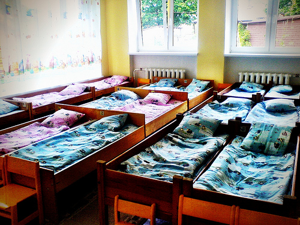

In [43]:
idx = 45
image = val_set['image'][idx]
image.thumbnail((300,400))
image

In [44]:
print(questions[idx], '\n\n', groundtruthAnswers[idx], '\n', 55*'-', '\n', generatedAnswers[idx])

Generate Step by Step Thought and the final answer from the given image and question: What color are the curtains? 

 Step-by-Step Thought:

1. I observe that the room has a window with a white frame.
2. I infer that the curtains are likely to be attached to the window frame.
3. Therefore, the curtains are probably yellow, as they match the color of the wall and the bed sheets.

 Final Answer: yellow 
 ------------------------------------------------------- 
 ?
model
Step-by-Step Thought:

1. I observe that the curtains are visible in the background of the image.
2. I infer that the curtains are white because they appear to be a light color and are not blocking the view of the room.
3. Therefore, the curtains are white.

 Final Answer: white


### Cosine

In [45]:
from sentence_transformers import SentenceTransformer, util
sbert = SentenceTransformer('all-mpnet-base-v2', device = 'cuda')

2026-03-08 18:22:46,950 - INFO - Load pretrained SentenceTransformer: all-mpnet-base-v2


In [46]:
def findCosSim(word1:str, word2:str) -> int:

    # Compute the embeddings
    embedding1 = sbert.encode(word1, convert_to_tensor=True)
    embedding2 = sbert.encode(word2, convert_to_tensor=True)
    
    # Compute cosine similarity
    cosine_score = util.pytorch_cos_sim(embedding1, embedding2)
    return round(cosine_score.item(), 2)

In [47]:
cosineAccuracy = [ findCosSim( generatedAnswers[idx], groundtruthAnswers[idx] ) for idx in tqdm(range(len(generatedAnswers))) ]

  0%|          | 0/600 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [48]:
round( ( sum(cosineAccuracy) / len(cosineAccuracy) ) * 100, 2)

82.58

### BERT Score
Precision (P): How much of the candidate's content is relevant.

Recall (R): How much of the reference's content is covered by the candidate.

F1 Score (F1): Harmonic mean of Precision and Recall, commonly used as the final metric.

In [49]:
from bert_score import score

# Example references and candidates
# references = ['stool','no','person','stool','sign','bronze','door','no','red','chair','red','black']
# candidates = ['stool','no','child','stool','sign','gold','picture','no','brown','chair','brown','black']

In [50]:
# Compute BERTScore, answerList_test = ground truth, result_list = model generated

P, R, F1 = score(generatedAnswers, groundtruthAnswers, lang="en", verbose=True, device='cuda')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/19 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/10 [00:00<?, ?it/s]

done in 4.82 seconds, 124.50 sentences/sec


In [51]:
# Print scores
print("Mean Precision:", np.round(np.mean(P.tolist())*100, 2) )
print("Mean Recall:", np.round(np.mean(R.tolist())*100, 2) )
print("Mean F1 Score:", np.round(np.mean(F1.tolist())*100, 2) )

Mean Precision: 92.48
Mean Recall: 92.22
Mean F1 Score: 92.33


### BLEU Scores

In [52]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [53]:
bleu_scores = []

# Function to compute BLEU-1 score for a list of ground truth and predicted answers
def calculate_bleu_1_score(ground_truth, predicted):

    # This sets BLEU-1 to only consider unigram precision
    weights = [1.0] + [0.0] * 3  
    
    # Smoothing function to handle cases with no n-gram matches
    smoothing_function = SmoothingFunction().method1  
    
    for gt, pred in zip(ground_truth, predicted):
        score = sentence_bleu([gt], pred, weights=weights, smoothing_function=smoothing_function)  
        bleu_scores.append(score)
    
    avg_bleu_score = sum(bleu_scores) / len(bleu_scores)
    
    return avg_bleu_score

In [54]:
# Calculate the BLEU score
avg_bleu = calculate_bleu_1_score(groundtruthAnswers, generatedAnswers)
print(f"Average BLEU score: {np.round(avg_bleu*100, 2)}")

Average BLEU score: 70.14


### ROUGE Score

In [55]:
from rouge_score import rouge_scorer

In [56]:
def calculate_avg_rouge_scores(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

    for ref, cand in zip(references, candidates):
        scores = scorer.score(ref, cand)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    return {
        "ROUGE-1": np.round(np.mean(rouge1_scores), 4),
        "ROUGE-2": np.round(np.mean(rouge2_scores), 4),
        "ROUGE-L": np.round(np.mean(rougeL_scores), 4),
    }

In [57]:
avg_rouge = calculate_avg_rouge_scores(groundtruthAnswers, generatedAnswers)
avg_rouge = { k:round(v*100, 2) for k,v in avg_rouge.items()}
print("Average ROUGE scores:", avg_rouge)

2026-03-08 18:23:17,873 - INFO - Using default tokenizer.


Average ROUGE scores: {'ROUGE-1': np.float64(61.39), 'ROUGE-2': np.float64(38.42), 'ROUGE-L': np.float64(50.88)}


### Formatting Score

In [58]:
import re

In [59]:
def normalize(text):
    text = text.lower()
    text = text.replace("-", " ")
    text = text.replace("_", " ")
    text = re.sub(r'\s+', ' ', text)
    return text

In [60]:
def formatting_score(text):

    text_n = normalize(text)

    step_patterns = [
        r"step by step thought",
        r"step by step reasoning",
        r"step by step"
    ]

    final_patterns = [
        r"final answer"
    ]

    step_pos = None
    final_pos = None

    for p in step_patterns:
        m = re.search(p, text_n)
        if m:
            step_pos = m.start()
            break

    for p in final_patterns:
        m = re.search(p, text_n)
        if m:
            final_pos = m.start()
            break

    if step_pos is not None and final_pos is not None:
        if step_pos < final_pos:
            return 1.0
        else:
            return 0.5

    if step_pos is not None or final_pos is not None:
        return 0.25

    return 0.0

In [61]:
scores = [formatting_score(ans) for ans in generatedAnswers]

# for i, s in enumerate(scores):
#     print(f"Sample {i+1} score:", s)

avg_score = (sum(scores) / len(scores))*100

print("\nAverage formatting score:", round(avg_score, 4))


Average formatting score: 100.0


### Perplexity

In [62]:
def collate_fn_ppl(batch, processor, device):
    messages_list = []
    
    for item in batch:
        messages = [
            {
                "role": "system",
                "content": "You are a intelligent reasoning assistant who can generate step by step thought."
            },
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": item["image"]},
                    {"type": "text", "text": item["question"]},
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": item["cot_answer"]}
                ]
            }
        ]
        messages_list.append(messages)

    # Use add_generation_prompt=False to encode the full conversation
    texts = [
        processor.apply_chat_template(
            msg,
            tokenize=False,
            add_generation_prompt=False  
        )
        for msg in messages_list
    ]

    image_inputs, video_inputs = process_vision_info(messages_list)

    inputs = processor(
        text=texts,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    return inputs.to(device)

In [63]:
def compute_answer_only_perplexity(dataloader, device="cuda"):
    model.eval()
    batch_ppls = []

    # Get Qwen2-VL specific token IDs
    im_start_id = processor.tokenizer.convert_tokens_to_ids("<|im_start|>")
    image_pad_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    vision_start_id = processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
    vision_end_id = processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")

    # Determine dynamic offset for the "assistant\n" sequence
    # This precisely identifies where the generated answer starts
    assistant_suffix = processor.tokenizer.encode("assistant\n", add_special_tokens=False)
    offset = len(assistant_suffix)

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Calculating Perplexity"):

            # Ensure image float tensors are in the correct dtype (usually bfloat16)
            if "pixel_values" in batch:
                batch["pixel_values"] = batch["pixel_values"].to(model.dtype)
            if "image_features" in batch:
                batch["image_features"] = batch["image_features"].to(model.dtype)

            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]

            # Forward Pass
            outputs = model(**batch)
            logits = outputs.logits

            # Shift alignment for next-token prediction
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = input_ids[:, 1:].contiguous()
            shift_attention = attention_mask[:, 1:].contiguous()

            # Calculate raw log probabilities
            log_probs = torch.nn.functional.log_softmax(shift_logits.float(), dim=-1)

            target_log_probs = log_probs.gather(
                dim=-1,
                index=shift_labels.unsqueeze(-1)
            ).squeeze(-1)

            # Initialize answer mask natively handling PAD tokens through shift_attention
            answer_mask = shift_attention.clone().float()

            for i in range(input_ids.size(0)):
                im_start_positions = (input_ids[i] == im_start_id).nonzero(as_tuple=True)[0]

                if len(im_start_positions) == 0:
                    continue

                # The last occurrence of <|im_start|> signifies the assistant's turn
                last_im_start = im_start_positions[-1].item()

                # Zero out all prompt context up until the true answer starts
                mask_end_idx = last_im_start + offset
                answer_mask[i, :mask_end_idx] = 0

            # Explicitly mask out Vision structural and pad tokens
            if image_pad_id is not None:
                answer_mask[shift_labels == image_pad_id] = 0
            if vision_start_id is not None:
                answer_mask[shift_labels == vision_start_id] = 0
            if vision_end_id is not None:
                answer_mask[shift_labels == vision_end_id] = 0

            # Calculate NLL isolated only to the Answer region
            target_log_probs = target_log_probs * answer_mask

            batch_nll = -target_log_probs.sum(dim=-1)
            batch_tokens = answer_mask.sum(dim=-1)

            # Avoid division by zero clamping at 1.0 safely
            batch_mean_nll = batch_nll / batch_tokens.clamp(min=1.0)
            batch_ppl = torch.exp(batch_mean_nll)

            batch_ppls.extend(batch_ppl.tolist())

    final_ppl = sum(batch_ppls) / len(batch_ppls)
    return final_ppl

In [64]:
val_loader_ppl = DataLoader(
    val_set,
    batch_size=8,  # Adjust lower depending on GPU memory
    shuffle=False,
    collate_fn=partial(collate_fn_ppl, processor=processor, device="cuda")
)

In [65]:
# Run Calculation.
final_perplexity = compute_answer_only_perplexity(
    dataloader=val_loader_ppl, 
    device="cuda"
)

print(f"Final Answer-Only Perplexity: {final_perplexity:.4f}")

Calculating Perplexity:   0%|          | 0/75 [00:00<?, ?it/s]

ValueError: Received inconsistently sized batches of images (1) and text (8).